In [1]:
%load_ext autoreload
%autoreload 2

## Example of switchable guidances with a V1 missile simulation
Notebook designed to show how switchable guidances are built and work.

In [2]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from mad.configs import EARTH_SETTINGS, V1, V1_guidance
from mad.objs import Planet, PlanetConfig
from mad.objs import CruiseMissile, CruiseMissileConfig
from mad.guidances import (CruiseWaypointGuidance, CruiseGuidanceConfig, GuidanceManager, NoGuidanceNoThrust, HoldPosition)
from mad.guidances.interrupt_guidances import (interrupt_at_t, interrupt_at_linear_distance_to_target)
from mad.objs.launchers import Launcher, LauncherConfig
from mad.objs.battle_computers import BattleComputer, ComputerEvent, ComputerCommand, ComputerOrder
from mad.simulation import Simulation
from mad.utils.logger import SourceLogger
from mad.utils.plotters import plot_2D_planet_with_points, plot_ballistic_range_table_gamma
from mad.utils.ballistic_tables import load_ballistic_df

logger = SourceLogger()

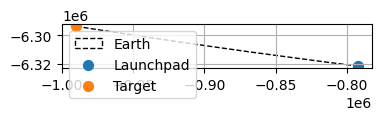

In [3]:
# FIrst, let's define the reference. planet erth, and 2 points on the surface. 
# One for launchpad and one for target, separated by 200 km.

EARTH_SETTINGS["position"] = [0.0, 0.0]

launchsite_target_distance_km = 200
earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = earth.random_point_at_surface(name="Launchpad", altitude=10)
target = earth.point_at_distance(launchpad, distance_km=launchsite_target_distance_km, name="Target")
plot_2D_planet_with_points(earth, points = [launchpad, target], display="arc");

From the V1 config files, we can see it has a maximum range of 250 km, it will be in range from launchpad to target.
Moreover, its max speed is around 170 m/s with a cruise altitude of 900 m.

In [4]:
V1, V1_guidance

({'name': 'V-1',
  'mass': 2150.0,
  'ref_radius': 0.3,
  'Cd': 0.5,
  'thrust_acc': 30.0,
  'max_range_m': 250000,
  'yield_kt': 0.0},
 {'max_speed_m_s': 177.77777777777777,
  'altitude_settling_time_s': 60.0,
  'cruise_altitude_m': 900.0})

The original V1 missile was set to nose-dive when in range of target, which stopped its motor.

In this case, we pre-calculated the ballistic table for the V1 missile.
We can see that at an altitude of 900 m and a speed of 170 m/s, it will still fly for around 2 - 3 km depending on gamma. 

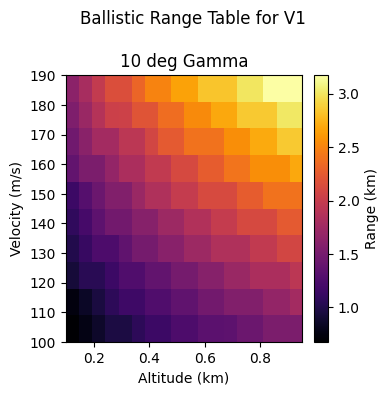

In [5]:
df = load_ballistic_df("V1")
plot_ballistic_range_table_gamma(df, selected_gamma=10, table_name="V1");

Let's define 2 guidances: one to fly from launchsite to target and a second one that will simply cut thrust and let the missile fall, following it trajectory.

In [6]:
fly_config = CruiseGuidanceConfig(waypoints=[launchpad, target], **V1_guidance)
fly = CruiseWaypointGuidance(planet=earth,
                            target=target, 
                            config=fly_config, 
                            # 3000 m, estimation from the ballistic table
                            interrupt_fn=partial(interrupt_at_linear_distance_to_target, 
                                                    reached_distance_m=3000) 
                            )

fall = NoGuidanceNoThrust(planet=earth, target=target)

# We assemble the 2 guidances into a guidance manager, which will switch from the first to the second 
# when the interrupt condition is met.
guidance_manager = GuidanceManager(guidances=[fly, fall])

# The full configuration for the V1 missile, including the guidance manager.
V1_config = CruiseMissileConfig(**V1, guidance=guidance_manager)

# And the V1 object.
V1_missile = CruiseMissile(position=launchpad.position.copy(), 
                           config=V1_config)
    

12:56:44 | INFO     | Guidance     | CruiseWaypointGuidance: spline built over 2 waypoints (3 dense points), total arc length 200.0 km.


Now, if we run the simulation, we can see in the logs that the missile flew until 3km from its target, then stopped its motor for a free fall.
It hits the ground and detonates 60 m away from the target.

In [7]:
dt = 1.0
max_time = 5_000.0  # enough for 1000 km at ~250 m/s

sim = Simulation(max_time=max_time, dt=dt)
sim.run(
    planet=earth,
    moving_objs=[V1_missile], # The only moving object is the missile
)

df = sim.results


12:56:47 | INFO     | Simulation   | 0.00s - Starting simulation.
12:56:47 | INFO     | Guidance     | 1037.00s - Switching to guidance law 1: NoGuidanceNoThrust
12:56:47 | INFO     | Missile      | 1051.00s - V-1 hit the ground at 60.60 m from target!
12:56:47 | INFO     | Missile      | 1051.00s - Warhead V-1 detonated with yield 0.00 kt.
12:56:47 | INFO     | Simulation   | 1051.00s - Simulation ended. Took 0.47 s of real time.


In [8]:
# Some post-processing to add useful columns to the dataframe.
df["altitude_km"] = df["position"].apply(lambda pos: (np.linalg.norm(pos) - earth.radius) / 1e3)
df["energy_kJ"] = df["speed"].apply(lambda speed: 0.5 * speed**2 / 1e3)
df["gamma_deg"] = df["gamma"].apply(lambda g: np.degrees(g) if g is not None else None)
df = df.sort_values(by=["name", "time"])

We can now plot the course of the missile, altitude and speed: 

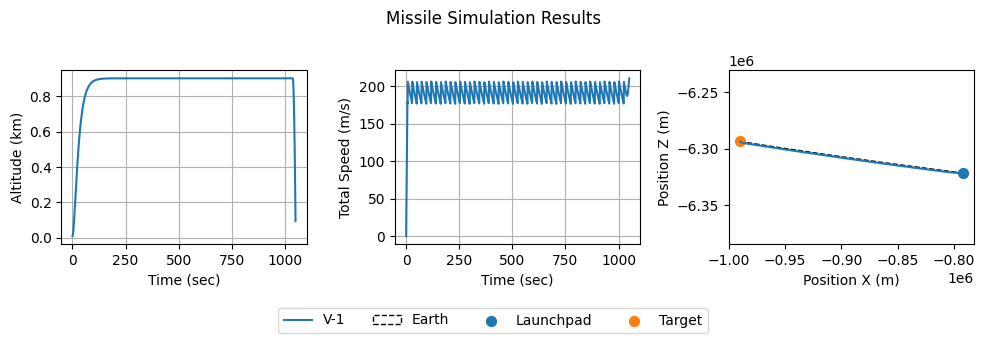

In [9]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(10, 3))
ax = ax.ravel()

sns.lineplot(data=df, x="time", y="altitude_km", hue="name", ax=ax[0])
sns.lineplot(data=df, x="time", y="speed", hue="name", ax=ax[1])
sns.lineplot(data=df, x="posx", y="posz", hue="name", ax=ax[2], sort=False, errorbar=None)

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")


plot_2D_planet_with_points(earth, points = [launchpad, target], ax=ax[2], display="arc")
ax[2].set_xlabel("Position X (m)")
ax[2].set_ylabel("Position Z (m)")
ax[2].set_aspect("equal", adjustable="datalim")

for a in ax:
    a.grid()
    a.legend()
    handles, labels = a.get_legend_handles_labels()
    a.legend().remove()

fig.suptitle("Missile Simulation Results")
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(pad=1.2)

This was done by simply adding the missile in the simulation. But what if we want more complex scenario?
We will need to use a launcher for the V1 and a battle computer to manage the launcher.  

In [16]:
launcher_config = LauncherConfig(
    projectiles=V1_config,
    name="V1 Launcher",
    n_projectiles=5,
    reload_time=0.0,
    launch_delay=0.0,
)

launcher = Launcher(config=launcher_config, position=launchpad.position.copy())

In [17]:

# Let's launch V1s at 5 and 15s of the simultion time.
# The launcher will take care of the launch delay and reload time.
events = [
    ComputerEvent(
        time=5.0,
        command=ComputerCommand(
            order=ComputerOrder.LAUNCH
        )
    ),
    ComputerEvent(
        time=50.0,
        command=ComputerCommand(
            order=ComputerOrder.LAUNCH
        )
    )
]

battle_computer = BattleComputer(
    name="V1 Battle Computer",
)

battle_computer.position = launchpad.position.copy()
battle_computer.launchers=[launcher]
battle_computer.events=events

In [18]:
dt = 1.0
max_time = 1_200.0

sim = Simulation(max_time=max_time, dt=dt)
# We don't want to collect data for the battle computer or the launcher.
sim.collector.ignore_objects = [battle_computer, launcher] 
sim.run(
    planet=earth,
    moving_objs=[launcher, battle_computer], # The only moving object is the missile
)

df = sim.results

12:59:26 | INFO     | Simulation   | 0.00s - Starting simulation.
12:59:26 | INFO     | Simulation   | 5.00s - New objects spawned this step: ['V-1']
12:59:26 | INFO     | Simulation   | 50.00s - New objects spawned this step: ['V-1']
12:59:27 | INFO     | Guidance     | 1041.00s - Switching to guidance law 1: NoGuidanceNoThrust
12:59:27 | INFO     | Missile      | 1055.00s - V-1 hit the ground at 60.60 m from target!
12:59:27 | INFO     | Missile      | 1055.00s - Warhead V-1 detonated with yield 0.00 kt.
12:59:27 | INFO     | Guidance     | 1086.00s - Switching to guidance law 1: NoGuidanceNoThrust
12:59:27 | INFO     | Missile      | 1100.00s - V-1 hit the ground at 60.60 m from target!
12:59:27 | INFO     | Missile      | 1100.00s - Warhead V-1 detonated with yield 0.00 kt.
12:59:27 | INFO     | Simulation   | 1200.00s - Simulation ended. Took 1.00 s of real time.


In [19]:
# Some post-processing to add useful columns to the dataframe.
df["altitude_km"] = df["position"].apply(lambda pos: (np.linalg.norm(pos) - earth.radius) / 1e3)
df["energy_kJ"] = df["speed"].apply(lambda speed: 0.5 * speed**2 / 1e3)
df["gamma_deg"] = df["gamma"].apply(lambda g: np.degrees(g) if g is not None else None)
df = df.sort_values(by=["name", "time"])

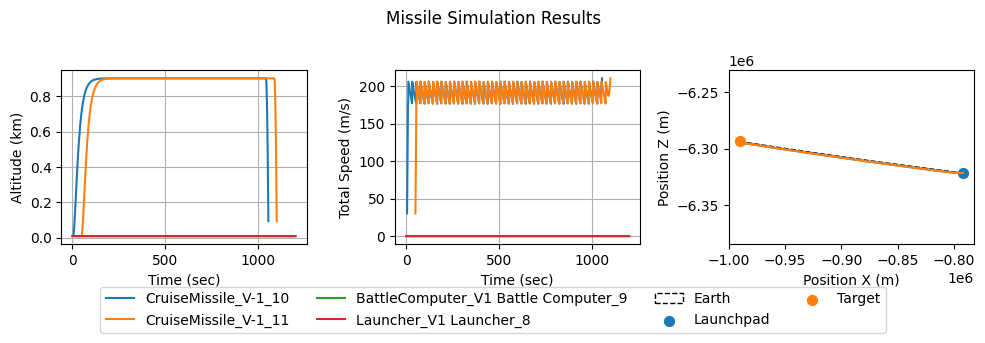

In [20]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(10, 3))
ax = ax.ravel()

sns.lineplot(data=df, x="time", y="altitude_km", hue="_id", ax=ax[0])
sns.lineplot(data=df, x="time", y="speed", hue="_id", ax=ax[1])
sns.lineplot(data=df, x="posx", y="posz", hue="_id", ax=ax[2], sort=False, errorbar=None)

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")


plot_2D_planet_with_points(earth, points = [launchpad, target], ax=ax[2], display="arc")
ax[2].set_xlabel("Position X (m)")
ax[2].set_ylabel("Position Z (m)")
ax[2].set_aspect("equal", adjustable="datalim")

for a in ax:
    a.grid()
    a.legend()
    handles, labels = a.get_legend_handles_labels()
    a.legend().remove()

fig.suptitle("Missile Simulation Results")
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(pad=1.2)